# Tamil Nadu Paddy Disease Risk Forecasting
**Pipeline:** Data Collection → Feature Engineering → Label Generation → Model Training (RF, XGBoost, LSTM, GRU, TCN) → Evaluation → Ensemble → Forecast

## 1. Install & Import

In [ ]:
!pip install openmeteo-requests requests-cache retry-requests -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.6/208.6 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 720.2/720.2 kB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 399.4/399.4 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 44.2 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import openmeteo_requests
import requests_cache
from retry_requests import retry

from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras import layers, Model

print('All imports successful.')
print(f'TensorFlow version: {tf.__version__}')

All imports successful.
TensorFlow version: 2.19.0


## 2. Configuration

In [ ]:
# --- District Coordinates ---
LOCATIONS = {
    'Thanjavur':    {'lat': 10.7852, 'lon': 79.1391},
    'Nilgiris':     {'lat': 11.4916, 'lon': 76.7337},
    'Chennai':      {'lat': 13.0827, 'lon': 80.2707},
    'Virudhunagar': {'lat':  9.5680, 'lon': 77.9624},
    'Nagapattinam': {'lat': 10.7656, 'lon': 79.8428},
}

# --- Model & Pipeline Constants ---
WINDOW_SIZE   = 7
SPLIT_RATIO   = 0.8
DISEASES      = ['Leaf Blast', 'Brown Spot', 'BLB', 'Tungro']
RISK_LEVELS   = ['Low', 'Medium', 'High']
TARGET_COLS   = ['leaf_blast_risk', 'brown_spot_risk', 'blb_risk', 'tungro_risk']

# --- File Paths ---
CSV_PATH   = 'tamilnadu_weather_2020_2025.csv'
SCALER_PATH = 'scaler.pkl'
MODEL_PATHS = {
    'rf':   'random_forest_model.pkl',
    'xgb':  'xgboost_model.pkl',
    'lstm': 'paddy_lstm_multi_output.h5',
    'gru':  'paddy_gru_multi_output.h5',
    'tcn':  'paddy_tcn_multi_output.h5',
}

print('Configuration set.')

Configuration set.


## 3. Data Collection (Historical Weather via Open-Meteo Archive API)

In [ ]:
cache_session  = requests_cache.CachedSession('.cache', expire_after=-1)
retry_session  = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo      = openmeteo_requests.Client(session=retry_session)

ARCHIVE_URL    = 'https://archive-api.open-meteo.com/v1/archive'
DAILY_VARS     = [
    'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min',
    'relative_humidity_2m_mean', 'precipitation_sum',
    'wind_speed_10m_max', 'soil_moisture_0_to_7cm_mean'
]

all_frames = []

for district, coord in LOCATIONS.items():
    print(f'Fetching data for {district}...')
    params = {
        'latitude':   coord['lat'],
        'longitude':  coord['lon'],
        'start_date': '2020-01-01',
        'end_date':   '2025-12-31',
        'daily':      DAILY_VARS,
        'timezone':   'auto',
    }
    response = openmeteo.weather_api(ARCHIVE_URL, params=params)[0]
    daily    = response.Daily()

    df_district = pd.DataFrame({
        'date': pd.date_range(
            start=pd.to_datetime(daily.Time() + response.UtcOffsetSeconds(), unit='s', utc=True),
            end=pd.to_datetime(daily.TimeEnd() + response.UtcOffsetSeconds(), unit='s', utc=True),
            freq=pd.Timedelta(seconds=daily.Interval()),
            inclusive='left'
        ),
        'temperature_mean': daily.Variables(0).ValuesAsNumpy(),
        'temperature_max':  daily.Variables(1).ValuesAsNumpy(),
        'temperature_min':  daily.Variables(2).ValuesAsNumpy(),
        'humidity':         daily.Variables(3).ValuesAsNumpy(),
        'rainfall':         daily.Variables(4).ValuesAsNumpy(),
        'wind_speed':       daily.Variables(5).ValuesAsNumpy(),
        'soil_moisture':    daily.Variables(6).ValuesAsNumpy(),
        'district':         district,
    })
    all_frames.append(df_district)

raw_df = pd.concat(all_frames, ignore_index=True).sort_values(['district', 'date'])
raw_df.to_csv(CSV_PATH, index=False)
print(f'\nSaved {len(raw_df):,} rows to {CSV_PATH}')
print(raw_df.head())

Fetching data for Thanjavur...
Fetching data for Nilgiris...
Fetching data for Chennai...
Fetching data for Virudhunagar...
Fetching data for Nagapattinam...

Saved 10,960 rows to tamilnadu_weather_2020_2025.csv
                          date  temperature_mean  temperature_max  \
4384 2020-01-01 00:00:00+00:00         25.047918        26.900000   
4385 2020-01-02 00:00:00+00:00         25.502083        27.299999   
4386 2020-01-03 00:00:00+00:00         26.147913        28.700001   
4387 2020-01-04 00:00:00+00:00         26.358332        28.750000   
4388 2020-01-05 00:00:00+00:00         26.104170        27.600000   

      temperature_min   humidity  rainfall  wind_speed  soil_moisture district  
4384        23.750000  87.857361  6.600000   13.684735       0.368083  Chennai  
4385        23.700001  88.324951  2.300000   11.592895       0.362208  Chennai  
4386        23.549999  84.923759  1.600000   11.770403       0.350708  Chennai  
4387        23.650000  84.767128  0.400000   12.8

## 4. Feature Engineering

In [ ]:
def add_rolling_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add per-district rolling statistics for temperature, humidity, and rainfall."""
    df = df.copy()
    for district in df['district'].unique():
        m = df['district'] == district
        df.loc[m, 'temp_avg_3d']      = df.loc[m, 'temperature_mean'].rolling(3).mean()
        df.loc[m, 'temp_avg_5d']      = df.loc[m, 'temperature_mean'].rolling(5).mean()
        df.loc[m, 'humidity_avg_3d']  = df.loc[m, 'humidity'].rolling(3).mean()
        df.loc[m, 'humidity_avg_5d']  = df.loc[m, 'humidity'].rolling(5).mean()
        df.loc[m, 'rainfall_sum_3d']  = df.loc[m, 'rainfall'].rolling(3).sum()
        df.loc[m, 'rainfall_sum_5d']  = df.loc[m, 'rainfall'].rolling(5).sum()
    return df


def add_interaction_and_time_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add interaction terms and calendar features."""
    df = df.copy()
    df['temp_humidity']     = df['temperature_mean'] * df['humidity']
    df['rainfall_humidity'] = df['rainfall'] * df['humidity']
    df['month']             = df['date'].dt.month
    df['day_of_year']       = df['date'].dt.dayofyear
    return df


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values(['district', 'date']).reset_index(drop=True)
    df = add_rolling_features(df)
    df = add_interaction_and_time_features(df)
    return df


# Load CSV (works whether data was just fetched or loaded from disk)
df = pd.read_csv(CSV_PATH)
df['date'] = pd.to_datetime(df['date'])
df = engineer_features(df)

print(df.shape)
df.head()

(10960, 19)


,date,temperature_mean,temperature_max,temperature_min,humidity,rainfall,wind_speed,soil_moisture,district,temp_avg_3d,temp_avg_5d,humidity_avg_3d,humidity_avg_5d,rainfall_sum_3d,rainfall_sum_5d,temp_humidity,rainfall_humidity,month,day_of_year
0,2020-01-01 00:00:00+00:00,25.047918,26.90,23.75,87.85736,6.600000,13.684735,0.368083,Chennai,NaN,NaN,NaN,NaN,NaN,NaN,2200.643949,579.858576,1,1
1,2020-01-02 00:00:00+00:00,25.502083,27.30,23.70,88.32495,2.300000,11.592895,0.362208,Chennai,NaN,NaN,NaN,NaN,NaN,NaN,2252.470206,203.147385,1,2
2,2020-01-03 00:00:00+00:00,26.147913,28.70,23.55,84.92376,1.600000,11.770403,0.350708,Chennai,25.565971,NaN,87.035357,NaN,10.500000,NaN,2220.579088,135.878016,1,3
3,2020-01-04 00:00:00+00:00,26.358332,28.75,23.65,84.76713,0.400000,12.819235,0.334292,Chennai,26.002776,NaN,86.005280,NaN,4.300000,NaN,2234.320155,33.906852,1,4
4,2020-01-05 00:00:00+00:00,26.104170,27.60,24.65,84.26856,5.299999,11.592894,0.351375,Chennai,26.203472,25.832083,84.653150,86.028352,7.299999,16.199999,2199.760816,446.623284,1,5


## 5. Risk Label Generation

In [ ]:
def generate_labels(df: pd.DataFrame) -> pd.DataFrame:
    """Assign 0/1/2 (Low/Medium/High) risk labels for four paddy diseases."""
    df = df.copy()
    for col in TARGET_COLS:
        df[col] = 0

    # Leaf Blast
    hi = (df['humidity_avg_3d'] > 85) & df['temp_avg_3d'].between(20, 28) & (df['rainfall_sum_3d'] > 5)
    md = (df['humidity'] > 75) & df['temperature_mean'].between(18, 30)
    df.loc[hi, 'leaf_blast_risk'] = 2
    df.loc[~hi & md, 'leaf_blast_risk'] = 1

    # Brown Spot
    hi = (df['temp_avg_3d'] > 30) & (df['rainfall_sum_5d'] < 5)
    md = df['temperature_mean'] > 28
    df.loc[hi, 'brown_spot_risk'] = 2
    df.loc[~hi & md, 'brown_spot_risk'] = 1

    # BLB (Bacterial Leaf Blight)
    hi = (df['rainfall_sum_3d'] > 10) & (df['wind_speed'] > 20) & (df['temperature_mean'] > 25)
    md = df['rainfall'] > 5
    df.loc[hi, 'blb_risk'] = 2
    df.loc[~hi & md, 'blb_risk'] = 1

    # Tungro
    hi = (df['humidity_avg_5d'] > 80) & df['temperature_mean'].between(25, 32)
    md = df['humidity'] > 70
    df.loc[hi, 'tungro_risk'] = 2
    df.loc[~hi & md, 'tungro_risk'] = 1

    return df


df = generate_labels(df)

# Inspect label distribution
for col in TARGET_COLS:
    print(f'{col}:', df[col].value_counts().to_dict())

leaf_blast_risk: {0: 7095, 1: 3155, 2: 710}
brown_spot_risk: {0: 6108, 1: 3403, 2: 1449}
blb_risk: {0: 8323, 1: 2161, 2: 476}
tungro_risk: {1: 5464, 0: 3975, 2: 1521}


## 6. Prepare Train / Test Data

In [ ]:
# Drop NaNs introduced by rolling windows and one-hot encode district
df = df.dropna().reset_index(drop=True)
df = pd.get_dummies(df, columns=['district'])

FEATURE_COLS = [
    'temperature_mean', 'temperature_max', 'temperature_min',
    'humidity', 'rainfall', 'wind_speed',
    'temp_avg_3d', 'temp_avg_5d',
    'humidity_avg_3d', 'humidity_avg_5d',
    'rainfall_sum_3d', 'rainfall_sum_5d',
    'temp_humidity', 'rainfall_humidity',
    'month', 'day_of_year'
] + [c for c in df.columns if c.startswith('district_')]


def create_sequences(df: pd.DataFrame, feature_cols: list, target_cols: list, window: int):
    """Slide a window over the dataframe to build (X, y) arrays."""
    data = df[feature_cols + target_cols].values
    n    = len(feature_cols)
    X    = np.array([data[i:i+window, :n]         for i in range(len(data) - window)])
    y    = np.array([data[i+window, n:]            for i in range(len(data) - window)])
    return X, y


X, y = create_sequences(df, FEATURE_COLS, TARGET_COLS, WINDOW_SIZE)

split = int(len(X) * SPLIT_RATIO)
X_train, X_test = X[:split].astype(np.float32), X[split:].astype(np.float32)
y_train, y_test = y[:split].astype(np.int32),   y[split:].astype(np.int32)

# Scale features
scaler          = StandardScaler()
X_train_scaled  = scaler.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
X_test_scaled   = scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)
joblib.dump(scaler, SCALER_PATH)

# Flat versions for tree models
X_train_flat = X_train_scaled.reshape(X_train_scaled.shape[0], -1)
X_test_flat  = X_test_scaled.reshape(X_test_scaled.shape[0], -1)

# Remove any remaining NaN rows
mask = ~np.isnan(y_train).any(axis=1)
X_train_flat, y_train = X_train_flat[mask], y_train[mask]
X_train_scaled        = X_train_scaled[mask]

mask = ~np.isnan(y_test).any(axis=1)
X_test_flat, y_test = X_test_flat[mask], y_test[mask]
X_test_scaled       = X_test_scaled[mask]

print('X_train:', X_train_scaled.shape, ' y_train:', y_train.shape)
print('X_test: ', X_test_scaled.shape,  ' y_test: ', y_test.shape)
print(f'Unique label values: {np.unique(y_train)}')

X_train: (8746, 7, 21)  y_train: (8746, 4)
X_test:  (2187, 7, 21)  y_test:  (2187, 4)
Unique label values: [0 1 2]


## 7. Train Models
### 7a. Random Forest

In [ ]:
model_rf = MultiOutputClassifier(
    RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42, n_jobs=-1)
)
model_rf.fit(X_train_flat, y_train)
joblib.dump(model_rf, MODEL_PATHS['rf'])
print('Random Forest trained and saved.')

Random Forest trained and saved.


### 7b. XGBoost

In [ ]:
model_xgb = MultiOutputClassifier(
    XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, tree_method='hist',
        random_state=42, eval_metric='mlogloss'
    )
)
model_xgb.fit(X_train_flat, y_train)
joblib.dump(model_xgb, MODEL_PATHS['xgb'])
print('XGBoost trained and saved.')

XGBoost trained and saved.


### 7c. Helper: Build Multi-Head Sequence Model

In [ ]:
def build_sequence_model(backbone: str, input_shape: tuple) -> Model:
    """
    Build a multi-output Keras model.
    backbone: 'lstm' | 'gru' | 'tcn'
    """
    inputs = layers.Input(shape=input_shape)

    if backbone == 'lstm':
        x = layers.LSTM(64)(inputs)
    elif backbone == 'gru':
        x = layers.GRU(64)(inputs)
    else:  # tcn (1-D CNN)
        x = layers.Conv1D(64, kernel_size=3, activation='relu')(inputs)
        x = layers.Conv1D(64, kernel_size=3, activation='relu')(x)
        x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation='relu')(x)

    outputs = {
        'leaf_blast':  layers.Dense(3, activation='softmax', name='leaf_blast')(x),
        'brown_spot':  layers.Dense(3, activation='softmax', name='brown_spot')(x),
        'blb':         layers.Dense(3, activation='softmax', name='blb')(x),
        'tungro':      layers.Dense(3, activation='softmax', name='tungro')(x),
    }

    model = Model(inputs=inputs, outputs=list(outputs.values()))
    model.compile(
        optimizer='adam',
        loss={k: 'sparse_categorical_crossentropy' for k in outputs},
        metrics={k: ['accuracy'] for k in outputs}
    )
    return model


INPUT_SHAPE = (X_train_scaled.shape[1], X_train_scaled.shape[2])

# Label dict helper
LABEL_KEYS = ['leaf_blast', 'brown_spot', 'blb', 'tungro']

def to_label_dict(y_arr):
    return {k: y_arr[:, i] for i, k in enumerate(LABEL_KEYS)}

print('Model builder ready. Input shape:', INPUT_SHAPE)

Model builder ready. Input shape: (7, 21)


### 7d. LSTM

In [ ]:
model_lstm = build_sequence_model('lstm', INPUT_SHAPE)
model_lstm.fit(
    X_train_scaled, to_label_dict(y_train),
    validation_data=(X_test_scaled, to_label_dict(y_test)),
    epochs=20, batch_size=32, verbose=1
)
model_lstm.save(MODEL_PATHS['lstm'])
print('LSTM trained and saved.')

Epoch 1/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - blb_accuracy: 0.7382 - blb_loss: 0.6127 - brown_spot_accuracy: 0.7681 - brown_spot_loss: 0.5192 - leaf_blast_accuracy: 0.7170 - leaf_blast_loss: 0.6216 - loss: 2.3927 - tungro_accuracy: 0.7150 - tungro_loss: 0.6367 - val_blb_accuracy: 0.8034 - val_blb_loss: 0.5375 - val_brown_spot_accuracy: 0.7032 - val_brown_spot_loss: 0.6168 - val_leaf_blast_accuracy: 0.8569 - val_leaf_blast_loss: 0.3362 - val_loss: 1.9316 - val_tungro_accuracy: 0.8130 - val_tungro_loss: 0.4352
Epoch 2/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - blb_accuracy: 0.7965 - blb_loss: 0.5112 - brown_spot_accuracy: 0.8724 - brown_spot_loss: 0.2930 - leaf_blast_accuracy: 0.7917 - leaf_blast_loss: 0.4632 - loss: 1.7281 - tungro_accuracy: 0.8055 - tungro_loss: 0.4597 - val_blb_accuracy: 0.8121 - val_blb_loss: 0.5131 - val_brown_spot_accuracy: 0.7357 - val_brown_spot_loss: 0.5332 - val_leaf_blast_accuracy: 0.8697 - val_leaf_blast_loss: 0.2926 - val_loss: 1.7309 - val_tungro

LSTM trained and saved.


### 7e. GRU

In [ ]:
model_gru = build_sequence_model('gru', INPUT_SHAPE)
model_gru.fit(
    X_train_scaled, to_label_dict(y_train),
    validation_data=(X_test_scaled, to_label_dict(y_test)),
    epochs=20, batch_size=32, verbose=1
)
model_gru.save(MODEL_PATHS['gru'])
print('GRU trained and saved.')

Epoch 1/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - blb_accuracy: 0.7725 - blb_loss: 0.5851 - brown_spot_accuracy: 0.8005 - brown_spot_loss: 0.4525 - leaf_blast_accuracy: 0.7214 - leaf_blast_loss: 0.6243 - loss: 2.2622 - tungro_accuracy: 0.7389 - tungro_loss: 0.5978 - val_blb_accuracy: 0.8002 - val_blb_loss: 0.5136 - val_brown_spot_accuracy: 0.7074 - val_brown_spot_loss: 0.5741 - val_leaf_blast_accuracy: 0.8441 - val_leaf_blast_loss: 0.3427 - val_loss: 1.8635 - val_tungro_accuracy: 0.8258 - val_tungro_loss: 0.4263
Epoch 2/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - blb_accuracy: 0.7929 - blb_loss: 0.5059 - brown_spot_accuracy: 0.8676 - brown_spot_loss: 0.2941 - leaf_blast_accuracy: 0.7976 - leaf_blast_loss: 0.4533 - loss: 1.6933 - tungro_accuracy: 0.8171 - tungro_loss: 0.4385 - val_blb_accuracy: 0.8089 - val_blb_loss: 0.4865 - val_brown_spot_accuracy: 0.7398 - val_brown_spot_loss: 0.5239 - val_leaf_blast_accuracy: 0.8619 - val_leaf_blast_loss: 0.3043 - val_loss: 1.7099 - val_tungro

GRU trained and saved.


### 7f. TCN (1D-CNN)

In [ ]:
model_tcn = build_sequence_model('tcn', INPUT_SHAPE)
model_tcn.fit(
    X_train_scaled, to_label_dict(y_train),
    validation_data=(X_test_scaled, to_label_dict(y_test)),
    epochs=20, batch_size=32, verbose=1
)
model_tcn.save(MODEL_PATHS['tcn'])
print('TCN trained and saved.')

Epoch 1/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - blb_accuracy: 0.7515 - blb_loss: 0.6221 - brown_spot_accuracy: 0.8119 - brown_spot_loss: 0.4391 - leaf_blast_accuracy: 0.6961 - leaf_blast_loss: 0.6333 - loss: 2.3379 - tungro_accuracy: 0.7152 - tungro_loss: 0.6426 - val_blb_accuracy: 0.7842 - val_blb_loss: 0.5608 - val_brown_spot_accuracy: 0.7462 - val_brown_spot_loss: 0.5664 - val_leaf_blast_accuracy: 0.8345 - val_leaf_blast_loss: 0.3749 - val_loss: 2.0409 - val_tungro_accuracy: 0.7650 - val_tungro_loss: 0.5422
Epoch 2/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - blb_accuracy: 0.7685 - blb_loss: 0.5529 - brown_spot_accuracy: 0.8550 - brown_spot_loss: 0.3226 - leaf_blast_accuracy: 0.7708 - leaf_blast_loss: 0.5082 - loss: 1.8948 - tungro_accuracy: 0.7840 - tungro_loss: 0.5133 - val_blb_accuracy: 0.7938 - val_blb_loss: 0.5273 - val_brown_spot_accuracy: 0.7718 - val_brown_spot_loss: 0.5023 - val_leaf_blast_accuracy: 0.8162 - val_leaf_blast_loss: 0.3979 - val_loss: 1.8945 - val_tungro

TCN trained and saved.


## 8. Model Performance Evaluation

In [ ]:
def get_predictions(model, X_flat=None, X_seq=None, model_type='tree'):
    """Return integer class predictions for each disease."""
    if model_type == 'tree':
        pred = model.predict(X_flat)          # shape (N, 4)
        return [pred[:, i] for i in range(4)]
    else:
        probs = model.predict(X_seq, verbose=0)
        return [np.argmax(p, axis=1) for p in probs]


def print_report(preds_dict):
    """Print classification reports for all models."""
    for model_name, preds in preds_dict.items():
        print(f'\n{'='*60}')
        print(f'  {model_name}')
        print(f'{'='*60}')
        for i, disease in enumerate(DISEASES):
            print(f'\n--- {disease} ---')
            print(classification_report(y_test[:, i], preds[i], zero_division=0))


# Get predictions from all models
preds_rf   = get_predictions(model_rf,   X_flat=X_test_flat, model_type='tree')
preds_xgb  = get_predictions(model_xgb,  X_flat=X_test_flat, model_type='tree')
preds_lstm = get_predictions(model_lstm, X_seq=X_test_scaled, model_type='seq')
preds_gru  = get_predictions(model_gru,  X_seq=X_test_scaled, model_type='seq')
preds_tcn  = get_predictions(model_tcn,  X_seq=X_test_scaled, model_type='seq')

all_preds = {
    'Random Forest': preds_rf,
    'XGBoost':       preds_xgb,
    'LSTM':          preds_lstm,
    'GRU':           preds_gru,
    'TCN':           preds_tcn,
}

print_report(all_preds)


  Random Forest

--- Leaf Blast ---
              precision    recall  f1-score   support

           0       0.95      0.92      0.93      1689
           1       0.66      0.73      0.70       402
           2       0.79      0.84      0.81        96

    accuracy                           0.88      2187
   macro avg       0.80      0.83      0.81      2187
weighted avg       0.89      0.88      0.88      2187


--- Brown Spot ---
              precision    recall  f1-score   support

           0       0.94      0.84      0.88       833
           1       0.81      0.88      0.84       838
           2       0.89      0.91      0.90       516

    accuracy                           0.87      2187
   macro avg       0.88      0.88      0.87      2187
weighted avg       0.88      0.87      0.87      2187


--- BLB ---
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1695
           1       0.67      0.34      0.45       437
     

## 9. Ensemble: XGBoost + TCN (Weighted Probability Averaging)

In [ ]:
xgb_probs = model_xgb.predict_proba(X_test_flat)  # list of 4 arrays, each (N, 3)
tcn_probs  = model_tcn.predict(X_test_scaled, verbose=0)

ensemble_weights = [0.1, 0.3, 0.5, 0.7, 0.9]  # XGBoost weight

for xgb_w in ensemble_weights:
    tcn_w = 1.0 - xgb_w
    print(f'\n### Ensemble XGB={xgb_w:.1f} / TCN={tcn_w:.1f} ###')
    for i, disease in enumerate(DISEASES):
        combined = xgb_probs[i] * xgb_w + tcn_probs[i] * tcn_w
        preds    = np.argmax(combined, axis=1)
        print(f'  {disease}: F1(weighted) = '
              f'{f1_score(y_test[:, i], preds, average="weighted", zero_division=0):.4f}')


### Ensemble XGB=0.1 / TCN=0.9 ###
  Leaf Blast: F1(weighted) = 0.8661
  Brown Spot: F1(weighted) = 0.8060
  BLB: F1(weighted) = 0.7809
  Tungro: F1(weighted) = 0.8354

### Ensemble XGB=0.3 / TCN=0.7 ###
  Leaf Blast: F1(weighted) = 0.8747
  Brown Spot: F1(weighted) = 0.8386
  BLB: F1(weighted) = 0.7794
  Tungro: F1(weighted) = 0.8433

### Ensemble XGB=0.5 / TCN=0.5 ###
  Leaf Blast: F1(weighted) = 0.8772
  Brown Spot: F1(weighted) = 0.8781
  BLB: F1(weighted) = 0.7835
  Tungro: F1(weighted) = 0.8481

### Ensemble XGB=0.7 / TCN=0.3 ###
  Leaf Blast: F1(weighted) = 0.8792
  Brown Spot: F1(weighted) = 0.8805
  BLB: F1(weighted) = 0.7848
  Tungro: F1(weighted) = 0.8453

### Ensemble XGB=0.9 / TCN=0.1 ###
  Leaf Blast: F1(weighted) = 0.8833
  Brown Spot: F1(weighted) = 0.8756
  BLB: F1(weighted) = 0.7838
  Tungro: F1(weighted) = 0.8503


## 10. Visual Performance Summary (F1 Comparison)


Overall Average Weighted F1-score:
XGBoost               0.8486
Random Forest         0.8455
LSTM                  0.8427
Ensemble (XGB=0.3)    0.8340
GRU                   0.8273
TCN                   0.8182


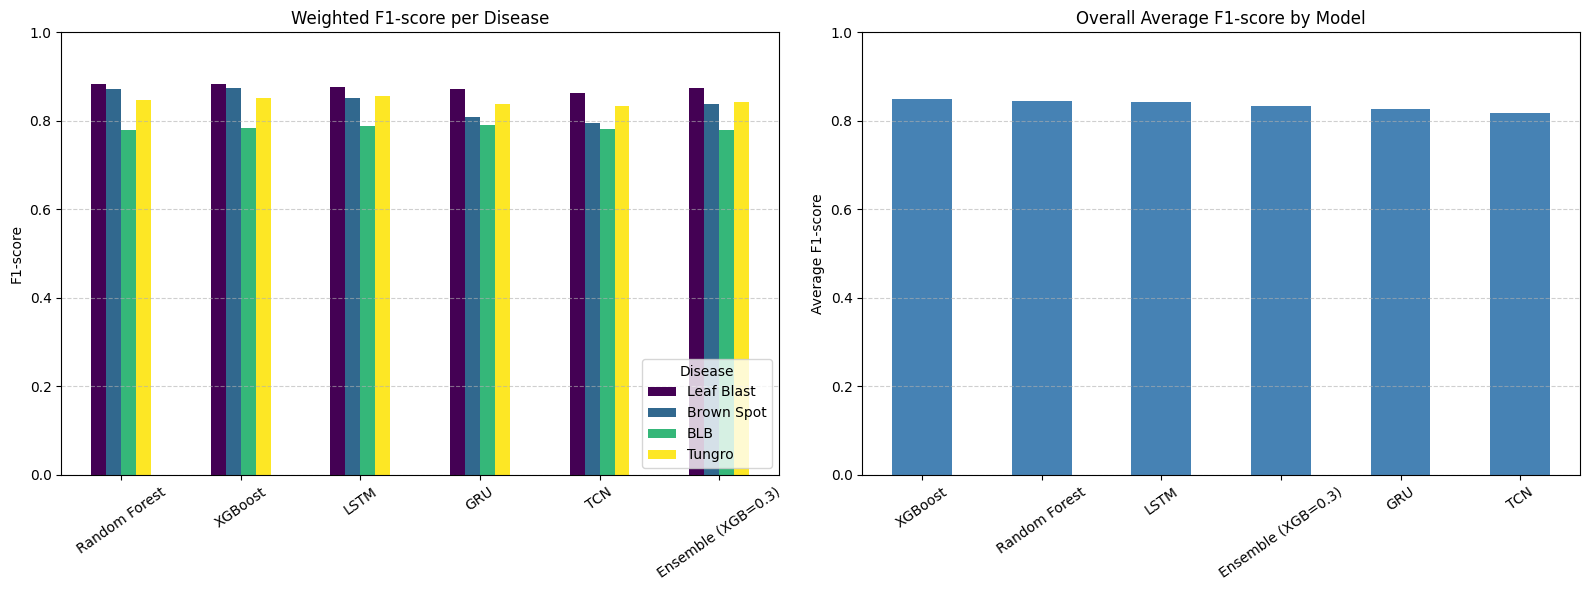

Chart saved as model_f1_comparison.png


In [ ]:
def compute_f1(preds_list):
    return [f1_score(y_test[:, i], preds_list[i], average='weighted', zero_division=0)
            for i in range(4)]


f1_scores = {name: compute_f1(preds) for name, preds in all_preds.items()}

# Best ensemble
best_w = 0.3  # adjust based on ablation above
ens_preds = [
    np.argmax(xgb_probs[i] * best_w + tcn_probs[i] * (1 - best_w), axis=1)
    for i in range(4)
]
f1_scores[f'Ensemble (XGB={best_w})'] = compute_f1(ens_preds)

df_f1 = pd.DataFrame(f1_scores, index=DISEASES).T
overall = df_f1.mean(axis=1).sort_values(ascending=False)

print('\nOverall Average Weighted F1-score:')
print(overall.round(4).to_string())

# Per-disease chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_f1.plot(kind='bar', ax=axes[0], colormap='viridis')
axes[0].set_title('Weighted F1-score per Disease')
axes[0].set_ylabel('F1-score')
axes[0].set_ylim(0, 1.0)
axes[0].tick_params(axis='x', rotation=35)
axes[0].legend(title='Disease', loc='lower right')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

overall.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Overall Average F1-score by Model')
axes[1].set_ylabel('Average F1-score')
axes[1].set_ylim(0, 1.0)
axes[1].tick_params(axis='x', rotation=35)
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('model_f1_comparison.png', dpi=150)
plt.show()
print('Chart saved as model_f1_comparison.png')

## 11. 7-Day Live Forecast

In [ ]:
SELECTED_DISTRICT = 'Nagapattinam'  # change as needed

FORECAST_URL = 'https://api.open-meteo.com/v1/forecast'
FORECAST_VARS = [
    'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min',
    'relative_humidity_2m_mean', 'precipitation_sum', 'wind_speed_10m_max'
]

coord = LOCATIONS[SELECTED_DISTRICT]
resp  = openmeteo.weather_api(FORECAST_URL, params={
    'latitude':     coord['lat'],
    'longitude':    coord['lon'],
    'daily':        FORECAST_VARS,
    'forecast_days': 7,
    'timezone':     'auto',
})[0]

d = resp.Daily()
forecast_df = pd.DataFrame({
    'date':             pd.date_range(
                            start=pd.to_datetime(d.Time() + resp.UtcOffsetSeconds(), unit='s', utc=True),
                            end=pd.to_datetime(d.TimeEnd() + resp.UtcOffsetSeconds(), unit='s', utc=True),
                            freq=pd.Timedelta(seconds=d.Interval()), inclusive='left'),
    'temperature_mean': d.Variables(0).ValuesAsNumpy(),
    'temperature_max':  d.Variables(1).ValuesAsNumpy(),
    'temperature_min':  d.Variables(2).ValuesAsNumpy(),
    'humidity':         d.Variables(3).ValuesAsNumpy(),
    'rainfall':         d.Variables(4).ValuesAsNumpy(),
    'wind_speed':       d.Variables(5).ValuesAsNumpy(),
    'district':         SELECTED_DISTRICT,
})

print(f'7-day forecast fetched for {SELECTED_DISTRICT}:')
display(forecast_df)

7-day forecast fetched for Nagapattinam:


,date,temperature_mean,temperature_max,temperature_min,humidity,rainfall,wind_speed,district
0,2026-04-10 00:00:00+00:00,29.414915,34.004498,26.904501,81.833336,0.1,11.177405,Nagapattinam
1,2026-04-11 00:00:00+00:00,28.887838,33.654499,26.104500,80.166664,0.0,11.013882,Nagapattinam
2,2026-04-12 00:00:00+00:00,28.787828,33.404499,25.854500,79.416664,0.0,10.390226,Nagapattinam
3,2026-04-13 00:00:00+00:00,28.667000,33.704498,24.904501,79.083336,0.0,9.746631,Nagapattinam
4,2026-04-14 00:00:00+00:00,28.946173,33.504498,25.604500,79.666664,0.0,10.137692,Nagapattinam
5,2026-04-15 00:00:00+00:00,29.239914,34.204498,25.804501,79.166664,0.0,10.805999,Nagapattinam
6,2026-04-16 00:00:00+00:00,29.435751,34.554497,26.304501,79.458336,0.0,9.255571,Nagapattinam


In [ ]:
# Combine WINDOW_SIZE-1 historical days + 7 forecast days for rolling features
hist_df = pd.read_csv(CSV_PATH)
hist_df['date'] = pd.to_datetime(hist_df['date'])
hist_district   = (hist_df[hist_df['district'] == SELECTED_DISTRICT]
                   .sort_values('date')
                   .tail(WINDOW_SIZE - 1)
                   [['date', 'temperature_mean', 'temperature_max', 'temperature_min',
                     'humidity', 'rainfall', 'wind_speed', 'district']])

combined = pd.concat([hist_district, forecast_df], ignore_index=True)
combined = add_rolling_features(combined)
combined = add_interaction_and_time_features(combined)

# One-hot encode
all_district_cols = [c for c in df.columns if c.startswith('district_')]
combined = combined.tail(7).reset_index(drop=True)

dummy = pd.DataFrame(0, index=combined.index, columns=all_district_cols)
dummy[f'district_{SELECTED_DISTRICT}'] = 1
combined_proc = pd.concat([combined.drop(columns=['district', 'date']), dummy], axis=1)

# Predict per forecast day using a rolling 7-day window
print(f'\n--- 7-Day Disease Risk Forecast: {SELECTED_DISTRICT} ---\n')
print(f'{"Date":<15} {"Leaf Blast":<15} {"Brown Spot":<15} {"BLB":<15} {"Tungro":<15}')
print('-' * 75)

# Build sequences from combined historical + forecast data
full_combined = pd.concat([hist_district.assign(**{c: 0 for c in all_district_cols}),
                            combined_proc], ignore_index=True)

for day_idx in range(7):
    window_data = combined_proc.iloc[max(0, day_idx - WINDOW_SIZE + 1): day_idx + 1][FEATURE_COLS]
    if len(window_data) < WINDOW_SIZE:
        continue  # skip days without a full window
    X_w = scaler.transform(window_data.values).reshape(1, WINDOW_SIZE, len(FEATURE_COLS))
    X_w_flat = X_w.reshape(1, -1)

    rf_pred = model_xgb.predict(X_w_flat)[0]
    date_str = str(forecast_df['date'].iloc[day_idx])[:10]
    row = f'{date_str:<15}' + ''.join(f'{RISK_LEVELS[int(rf_pred[i])]:<15}' for i in range(4))
    print(row)


--- 7-Day Disease Risk Forecast: Nagapattinam ---

Date            Leaf Blast      Brown Spot      BLB             Tungro         
---------------------------------------------------------------------------
2026-04-16     Medium         Medium         Low            Medium         


In [ ]:
import pickle
print(f"Pickle version: {pickle.format_version}")

Pickle version: 4.0
